In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

In [2]:
df = pd.read_csv('Car data.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.columns = df.columns.str.strip()

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB
None


In [5]:
print(df.isnull().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [6]:
df = df.dropna()

In [7]:
print(df.duplicated().sum())

763


In [8]:
duplicates = df[df.duplicated()]
print(duplicates)

                                 name  year  selling_price  km_driven    fuel  \
13                      Maruti 800 AC  2007          60000      70000  Petrol   
14           Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
15               Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
16             Datsun RediGO T Option  2017         250000      46000  Petrol   
17              Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   
...                               ...   ...            ...        ...     ...   
4307                 Mahindra Xylo H4  2019         599000      15000  Diesel   
4308              Maruti Alto 800 LXI  2018         200000      35000  Petrol   
4309                 Datsun GO Plus T  2017         350000      10171  Petrol   
4310  Renault Duster 110PS Diesel RxL  2015         465000      41123  Diesel   
4311          Toyota Camry Hybrid 2.5  2017        1900000      20118  Petrol   

     seller_type transmissi

In [9]:
df = df.drop_duplicates()

In [10]:
categorical_col = ["fuel","seller_type","transmission"]

for col in categorical_col:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

print("\nCategorical values normalized successfully!")


Categorical values normalized successfully!


In [11]:
# 1. Calculate Car Age from Year

current_year = datetime.now().year

df['car_age'] = current_year - df['year']

In [12]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [13]:
# 2. Extract Brand from Car_Name (first word of the car name)

df['brand'] = df['name'].apply(lambda x: str(x).split()[0].title())

In [14]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


In [27]:
print(df['selling_price'].max())

8900000


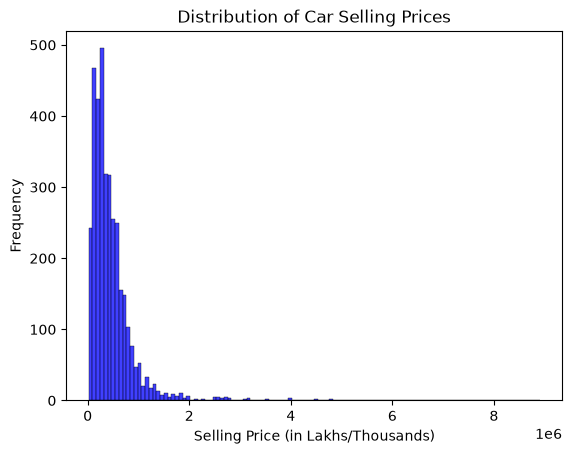

In [35]:
# 1. Distribution of Selling Prices

plt.Figure(figsize=(8,5))
sns.histplot(df['selling_price'],kde=False,color='blue')
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price (in Lakhs/Thousands)')
plt.ylabel('Frequency')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_5968\3233052071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel', y='selling_price', data=df, palette='Set2')


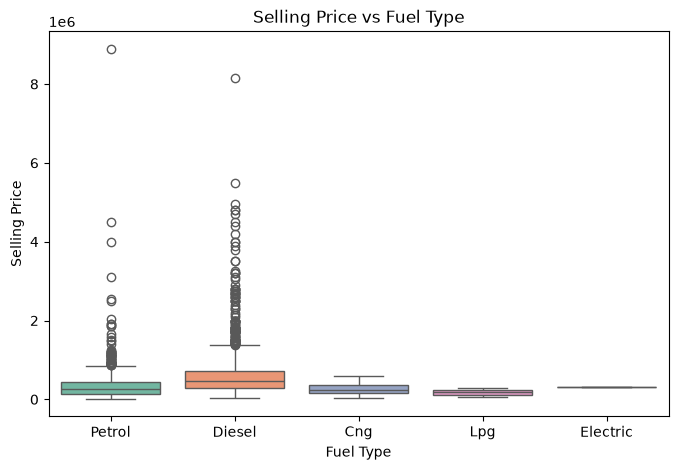

In [38]:
# 2. Selling Price vs. Fuel Type (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='fuel', y='selling_price', data=df, palette='Set2')
plt.title('Selling Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

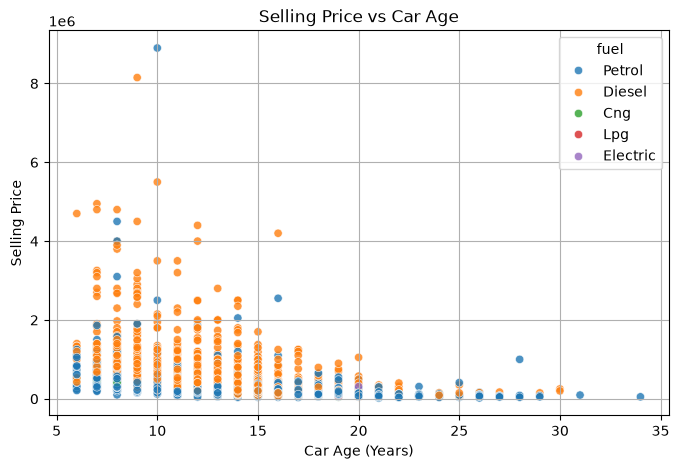

In [41]:
# 3. Selling Price vs. Car Age (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='car_age', y='selling_price', data=df, hue='fuel', alpha=0.8)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

In [47]:
# Drop high-cardinality/redundant original text columns before one-hot encoding
model_df = df.drop(columns=['name', 'year',])

In [48]:
# Convert categorical features to dummy variables (One-Hot Encoding)
model_df = pd.get_dummies(model_df, columns=['fuel', 'seller_type', 'transmission', 'brand','owner'], drop_first=True)

In [49]:
model_df.columns

Index(['selling_price', 'km_driven', 'car_age', 'fuel_Diesel', 'fuel_Electric',
       'fuel_Lpg', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Manual', 'brand_Audi',
       'brand_Bmw', 'brand_Chevrolet', 'brand_Daewoo', 'brand_Datsun',
       'brand_Fiat', 'brand_Force', 'brand_Ford', 'brand_Honda',
       'brand_Hyundai', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep',
       'brand_Kia', 'brand_Land', 'brand_Mahindra', 'brand_Maruti',
       'brand_Mercedes-Benz', 'brand_Mg', 'brand_Mitsubishi', 'brand_Nissan',
       'brand_Opelcorsa', 'brand_Renault', 'brand_Skoda', 'brand_Tata',
       'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo',
       'owner_Fourth & Above Owner', 'owner_Second Owner',
       'owner_Test Drive Car', 'owner_Third Owner'],
      dtype='str')

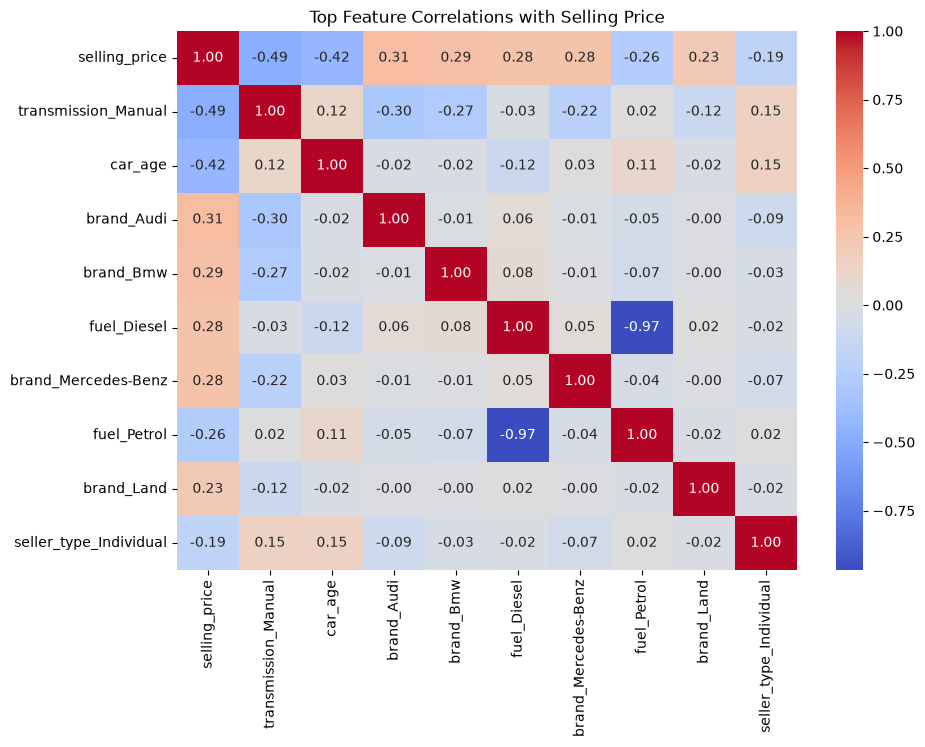

In [52]:
# Feature Correlation Heatmap
corr = model_df.corr()

top_features = (
    corr['selling_price']
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr.loc[top_features, top_features],
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Top Feature Correlations with Selling Price')
plt.show()

In [55]:
# Train / Test Split

X = model_df.drop('selling_price', axis=1)
y = model_df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (2861, 41), X_test shape: (716, 41)


In [57]:
# Model Training (Linear Regression & Random Forest)

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Both regression models trained successfully!")

Both regression models trained successfully!


In [58]:
# Model Evaluation (MAE, RMSE, R² Score)

def evaluate_model(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"=== {name} Performance ===")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}\n")
    return r2

r2_lr = evaluate_model(lr_model, X_test, y_test, "Linear Regression")
r2_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest Regressor")

=== Linear Regression Performance ===
MAE  : 185413.7602
RMSE : 380273.3547
R²   : 0.5511

=== Random Forest Regressor Performance ===
MAE  : 158510.4047
RMSE : 365448.4698
R²   : 0.5854



C:\Users\USER\AppData\Local\Temp\ipykernel_5968\4042660211.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


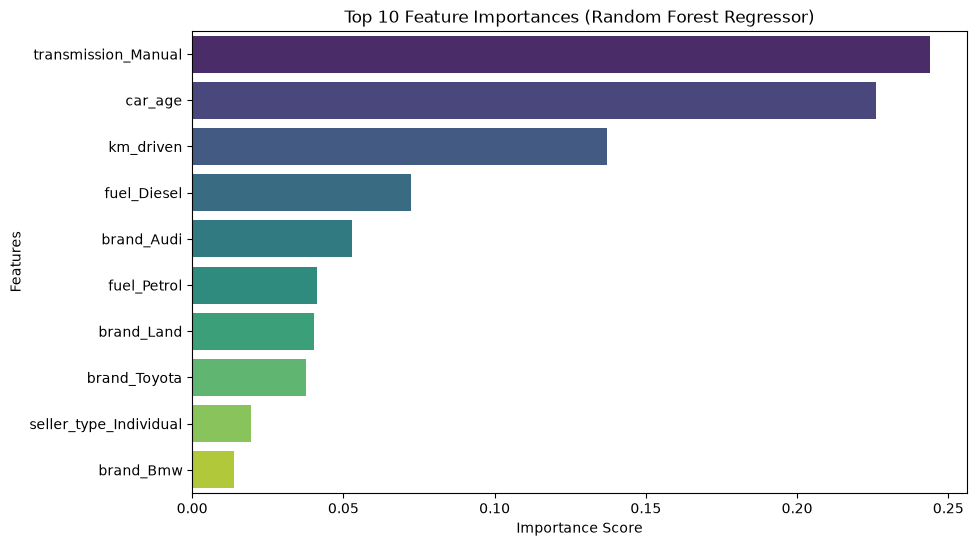

In [59]:
# Feature Importance Chart (Best Model: Random Forest)

importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest Regressor)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

"""
Conclusion & Model Selection:
The Random Forest Regressor outperformed Linear Regression with a higher R² score and lower RMSE/MAE.
Features such as 'Present_Price', 'Car_Age', and 'Driven_kms' played the most significant roles in 
determining the selling price of a used car.
"""